# 🏦 Loan Risk & Approval Prediction Analysis
## 1.1 Libraries and Data Loading
*Importing necessary tools for data manipulation, machine learning, and fairness evaluation.*

In [68]:
import pandas as pd
data=pd.read_csv("train.csv")
data_test=pd.read_csv("test.csv")

In [69]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [70]:
data_test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [71]:
data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [72]:
data.shape

(614, 13)

In [73]:
data_test.shape

(367, 12)

## 2.1 Handling Missing Values & Data Types
*Cleaning the dataset, replacing null values, and ensuring numeric columns (like Dependents) are correctly formatted.*



In [74]:
data.drop("Loan_ID", axis=1, inplace=True)
data_test.drop("Loan_ID", axis=1, inplace=True)


In [75]:
data.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [76]:
data_test.isnull().sum()

Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [77]:
numerical = []
categorical = []

for col in data.columns:
    if data[col].dtype in ["int64", "float64"]:
        numerical.append(col)
    elif data[col].dtype == "object":
        categorical.append(col)

categorical.remove("Loan_Status")

In [78]:
# Numerical
for col in numerical:
    mean_val = data[col].mean()
    data[col] = data[col].fillna(mean_val)
    data_test[col] = data_test[col].fillna(mean_val)

# Categorical
for col in categorical:
    mode_val = data[col].mode()[0]
    data[col] = data[col].fillna(mode_val)
    data_test[col] = data_test[col].fillna(mode_val)

In [79]:
data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [80]:
data_test.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [81]:
data.duplicated().sum()

0

In [82]:
data_test.duplicated().sum()

1

## 2.2 Visualizing Data Distribution & Outliers
*Identifying patterns, checking for class imbalance in Loan_Status, and detecting outliers in numerical columns like ApplicantIncome and LoanAmount.*

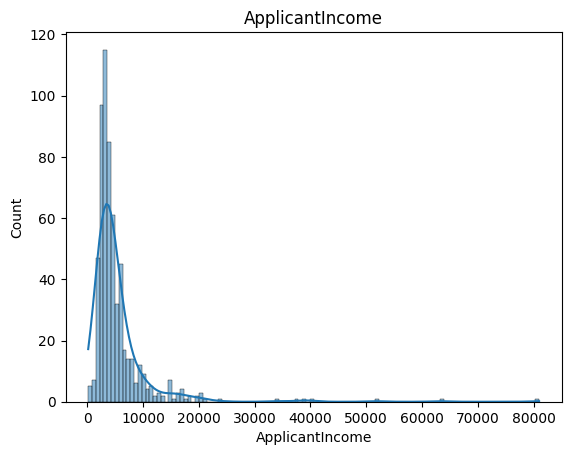

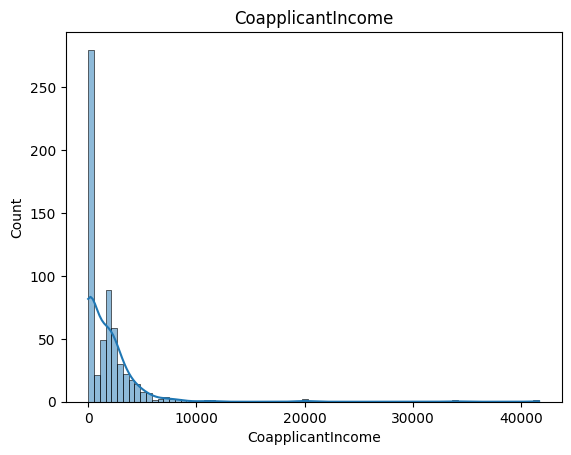

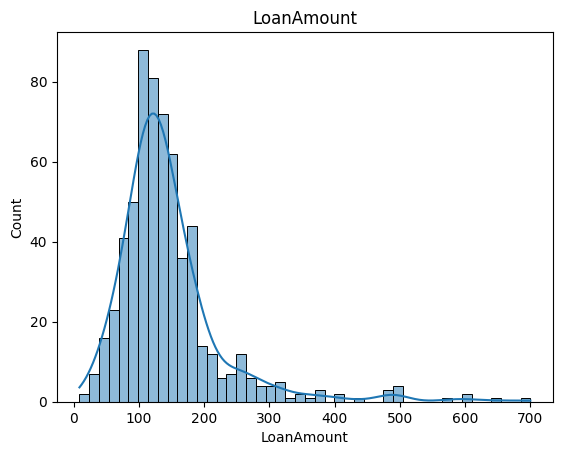

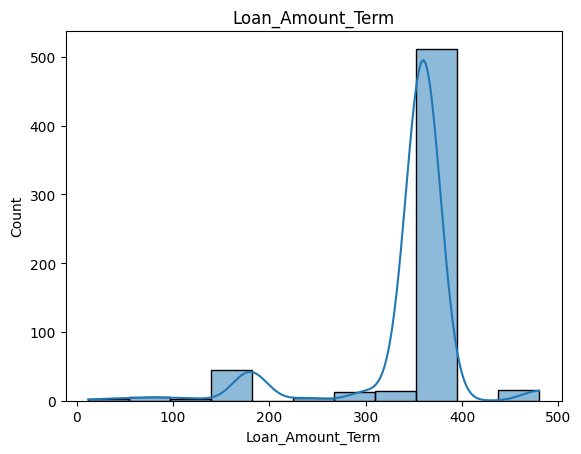

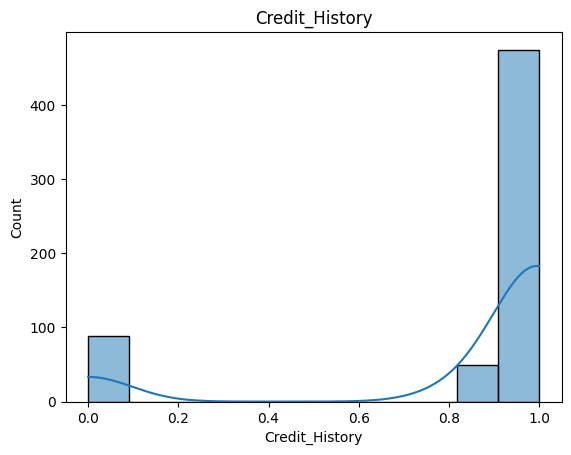

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numerical:
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

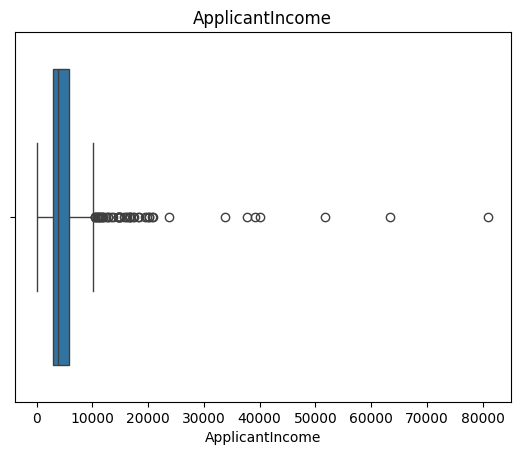

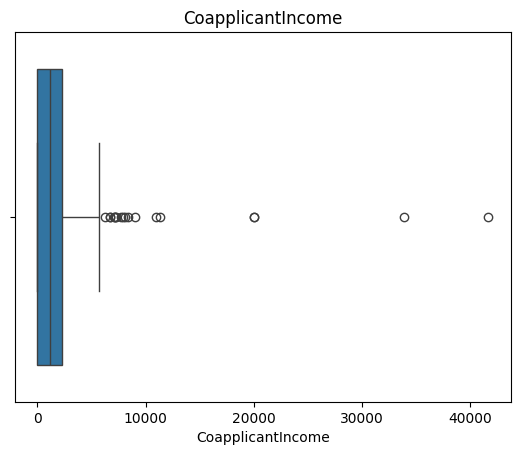

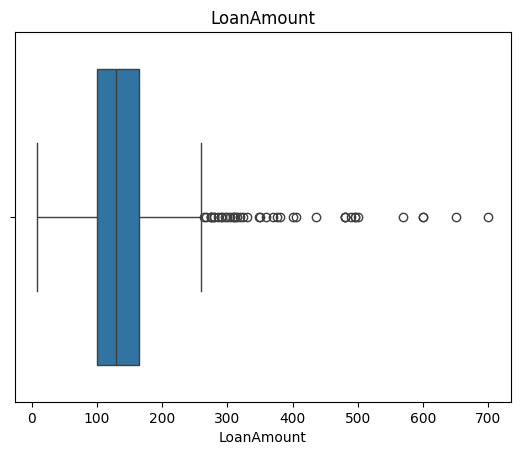

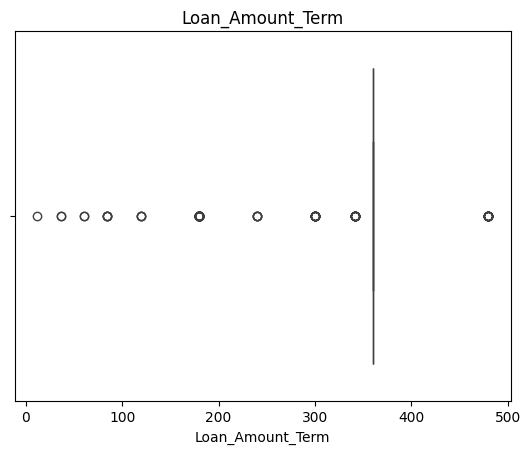

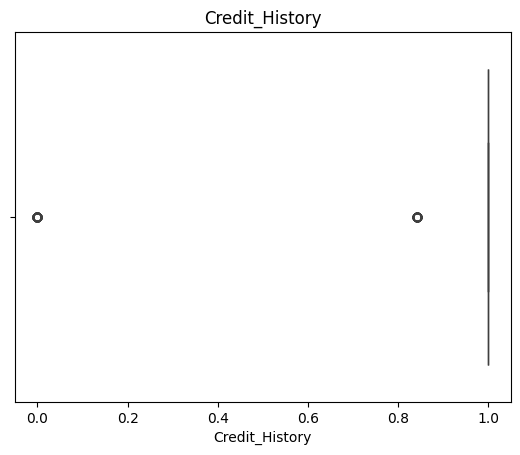

In [85]:
for col in numerical:
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

## Outliers Detection logic

In [86]:
for col in numerical:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(col, "→ Outliers:", len(outliers))

ApplicantIncome → Outliers: 50
CoapplicantIncome → Outliers: 18
LoanAmount → Outliers: 41
Loan_Amount_Term → Outliers: 102
Credit_History → Outliers: 139


In [87]:

for col in numerical:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR


    data[col] = data[col].clip(lower, upper)
    data_test[col] = data_test[col].clip(lower, upper)

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(col, "→ Outliers:", len(outliers))

ApplicantIncome → Outliers: 0
CoapplicantIncome → Outliers: 0
LoanAmount → Outliers: 0
Loan_Amount_Term → Outliers: 0
Credit_History → Outliers: 0


## 2.4 Transforming Categorical Variables
*Preparing data for Machine Learning by converting text labels into numerical formats using three strategies:*

1. **Label Encoding:** Applied to binary features (Gender, Married, etc.) to convert them to 0 and 1.
2. **Ordinal Encoding:** Applied to 'Dependents' to preserve the natural ranking (0 < 1 < 2 < 3+).
3. **One-Hot Encoding:** Applied to multi-category features (Property_Area) to create dummy variables without implying order.

In [89]:
label = []
onehot = []  
for col in categorical:
    unique_count = data[col].nunique()
    
    if unique_count == 2:
        label.append(col)
    else:
        onehot.append(col)


print(f"Label (Binary - will encode with 0/1): {label}")
print(f"Other (Will decide encoding later): {onehot}")

Label (Binary - will encode with 0/1): ['Gender', 'Married', 'Education', 'Self_Employed']
Other (Will decide encoding later): ['Dependents', 'Property_Area']


In [90]:
onehot.remove('Dependents')


In [91]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

In [92]:
label_encoder=LabelEncoder()
for col in label:
    data[col]=label_encoder.fit_transform(data[col])
    data_test[col]=label_encoder.transform(data_test[col])

In [93]:
ordinal=OrdinalEncoder(categories=[['0','1','2','3+']])
data['Dependents']=ordinal.fit_transform(data[['Dependents']])
data_test['Dependents']=ordinal.transform(data_test[['Dependents']])

In [94]:
from sklearn.preprocessing import OneHotEncoder

for col in onehot:
    onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)
    
    encoded_train = onehot_encoder.fit_transform(data[[col]])
    encoded_test = onehot_encoder.transform(data_test[[col]])
    
    feature_names = onehot_encoder.get_feature_names_out([col])
    
    encoded_train_df = pd.DataFrame(encoded_train, columns=feature_names, index=data.index)
    encoded_test_df = pd.DataFrame(encoded_test, columns=feature_names, index=data_test.index)
    
    data = pd.concat([data.drop(col, axis=1), encoded_train_df], axis=1)
    data_test = pd.concat([data_test.drop(col, axis=1), encoded_test_df], axis=1)  # FIXED: data_test not data_tesr

In [95]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,0,0,5849.0,0.0,146.412162,360.0,1.0,Y,0.0,1.0
1,1,1,1.0,0,0,4583.0,1508.0,128.000000,360.0,1.0,N,0.0,0.0
2,1,1,0.0,0,1,3000.0,0.0,66.000000,360.0,1.0,Y,0.0,1.0
3,1,1,0.0,1,0,2583.0,2358.0,120.000000,360.0,1.0,Y,0.0,1.0
4,1,0,0.0,0,0,6000.0,0.0,141.000000,360.0,1.0,Y,0.0,1.0


In [96]:
data_test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban
0,1,1,0.0,0,0,5720.0,0.0,110.0,360.0,1.0,0.0,1.0
1,1,1,1.0,0,0,3076.0,1500.0,126.0,360.0,1.0,0.0,1.0
2,1,1,2.0,0,0,5000.0,1800.0,208.0,360.0,1.0,0.0,1.0
3,1,1,2.0,0,0,2340.0,2546.0,100.0,360.0,1.0,0.0,1.0
4,1,0,0.0,1,0,3276.0,0.0,78.0,360.0,1.0,0.0,1.0


In [97]:
from sklearn.model_selection import train_test_split
x=data.drop('Loan_Status',axis=1)
y=data['Loan_Status']

X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [98]:
Y_train = Y_train.map({'Y': 1, 'N': 0})
Y_test = Y_test.map({'Y': 1, 'N': 0})

In [99]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[numerical]=scaler.fit_transform(X_train[numerical])
X_test[numerical]=scaler.transform(X_test[numerical])
data_test[numerical]=scaler.transform(data_test[numerical])

**Making copy of Data for model 2**

In [100]:
data_2=data.copy()

In [101]:
def calculate_risk(row):
    risk_score = 0

    if row['LoanAmount'] > 200:
        risk_score += 40
    elif row['LoanAmount'] > 120:
        risk_score += 25
    elif row['LoanAmount'] > 80:
        risk_score += 10
    
    # 2. Dependents (more dependents = higher risk)
    if row['Dependents'] in ['3+', 3]:
        risk_score += 30
    elif row['Dependents'] in ['2', 2]:
        risk_score += 20
    elif row['Dependents'] in ['1', 1]:
        risk_score += 10
    
    # 3. Income (lower income = higher risk)
    if row['ApplicantIncome'] < 2500:
        risk_score += 20
    elif row['ApplicantIncome'] < 4000:
        risk_score += 10
    
    # 4. Self Employed (slightly higher risk)
    if row['Self_Employed'] in ['Yes', 1]:
        risk_score += 10
    
    # Determine risk level
    if risk_score >= 50:
        return 'High'
    elif risk_score >= 25:
        return 'Medium'
    else:
        return 'Low'

In [102]:
data_2['Risk_Level'] = data_2.apply(calculate_risk, axis=1)
data_2.drop('Loan_Status', axis=1, inplace=True)


In [103]:
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data_2['Risk_Level'] = data_2['Risk_Level'].map(risk_mapping)

In [104]:
data_2.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban,Risk_Level
0,1,0,0.0,0,0,5849.0,0.0,146.412162,360.0,1.0,0.0,1.0,1
1,1,1,1.0,0,0,4583.0,1508.0,128.000000,360.0,1.0,0.0,0.0,1
2,1,1,0.0,0,1,3000.0,0.0,66.000000,360.0,1.0,0.0,1.0,0
3,1,1,0.0,1,0,2583.0,2358.0,120.000000,360.0,1.0,0.0,1.0,0
4,1,0,0.0,0,0,6000.0,0.0,141.000000,360.0,1.0,0.0,1.0,1


In [105]:
from sklearn.model_selection import train_test_split
X=data_2.drop('Risk_Level',axis=1)
Y=data_2['Risk_Level']

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


In [107]:
from xgboost import XGBClassifier
from collections import Counter

# Calculate for XGBoost
counter = Counter(Y_train)
scale_pos_weight = counter[0] / counter[1] if counter[1] > 0 else 1

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)
}

In [108]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    model.fit(X_train,Y_train)
    
    Y_pred = model.predict(X_test)
    
    acc = accuracy_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred)
    rec = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1-Score: {f1:.4f}")


Logistic Regression:
  Accuracy: 0.5854
  Precision: 0.7231
  Recall: 0.5875
  F1-Score: 0.6483

Decision Tree:
  Accuracy: 0.6179
  Precision: 0.6854
  Recall: 0.7625
  F1-Score: 0.7219

Random Forest:
  Accuracy: 0.5935
  Precision: 0.6364
  Recall: 0.8750
  F1-Score: 0.7368

KNN:
  Accuracy: 0.5772
  Precision: 0.6373
  Recall: 0.8125
  F1-Score: 0.7143

XGBoost:
  Accuracy: 0.6341
  Precision: 0.6923
  Recall: 0.7875
  F1-Score: 0.7368


In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    # For MULTI-CLASS, use average='weighted'
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1-Score: {f1:.4f}")

C:\Users\taran\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression:
  Accuracy: 0.8455
  Precision: 0.8472
  Recall: 0.8455
  F1-Score: 0.8449

Decision Tree:
  Accuracy: 0.9350
  Precision: 0.9362
  Recall: 0.9350
  F1-Score: 0.9352

Random Forest:
  Accuracy: 0.8862
  Precision: 0.9043
  Recall: 0.8862
  F1-Score: 0.8788

KNN:
  Accuracy: 0.5122
  Precision: 0.4870
  Recall: 0.5122
  F1-Score: 0.4638

XGBoost:
  Accuracy: 0.8862
  Precision: 0.8885
  Recall: 0.8862
  F1-Score: 0.8814


C:\Users\taran\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:57:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [110]:
from sklearn.model_selection import RandomizedSearchCV

# Same parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Random search (tries only 50 random combinations)
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    n_iter=50,               # Try 50 random combinations
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("✅ Best Parameters:", random_search.best_params_)
best_rf = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\taran\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1102: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


✅ Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 15, 'class_weight': 'balanced'}


In [111]:
print("="*50)
print("FINALIZING BEST MODELS")
print("="*50)

from sklearn.ensemble import RandomForestClassifier

final_model1 = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=200,      # Good default
    max_depth=15,          # Good default
    n_jobs=-1
)

final_model1.fit(X_train, Y_train)

from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

Y_pred1 = final_model1.predict(X_test)
print("\n📊 MODEL 1: Random Forest (Loan Approval)")
print(f"   Accuracy:  {accuracy_score(Y_test, Y_pred1):.4f}")
print(f"   Precision: {precision_score(Y_test, Y_pred1):.4f}")
print(f"   Recall:    {recall_score(Y_test, Y_pred1):.4f}")
print(f"   F1-Score:  {f1_score(Y_test, Y_pred1):.4f}")

from sklearn.tree import DecisionTreeClassifier

final_model2 = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=10,          # Good default
    min_samples_split=5    # Good default
)

# Train on FULL training data
final_model2.fit(x_train, y_train)

# Quick evaluation
y_pred2 = final_model2.predict(x_test)
print("\n📊 MODEL 2: Decision Tree (Risk Prediction)")
print(f"   Accuracy:  {accuracy_score(y_test, y_pred2):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred2, average='weighted'):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred2, average='weighted'):.4f}")
print(f"   F1-Score:  {f1_score(y_test, y_pred2, average='weighted'):.4f}")

print("\n" + "="*50)
print("✅ MODELS FINALIZED!")
print("="*50)
print(f"🏆 Model 1 (Loan Approval): Random Forest")
print(f"🏆 Model 2 (Risk Prediction): Decision Tree")

FINALIZING BEST MODELS

📊 MODEL 1: Random Forest (Loan Approval)
   Accuracy:  0.5935
   Precision: 0.6339
   Recall:    0.8875
   F1-Score:  0.7396

📊 MODEL 2: Decision Tree (Risk Prediction)
   Accuracy:  0.9268
   Precision: 0.9293
   Recall:    0.9268
   F1-Score:  0.9273

✅ MODELS FINALIZED!
🏆 Model 1 (Loan Approval): Random Forest
🏆 Model 2 (Risk Prediction): Decision Tree


In [112]:
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate
from functools import partial

# 1. Define custom metrics to fix the 'pos_label' error
# We assume 1 = Approved, 0 = Rejected
fpr_custom = partial(false_positive_rate, pos_label=1)
fnr_custom = partial(false_negative_rate, pos_label=1)

# 2. Identify the sensitive feature for the test set
# Replace 'Gender' with the column you want to check for bias
sensitive_feature1 = data.loc[X_test.index, 'Gender']

# 3. Create the MetricFrame
mf1 = MetricFrame(
    metrics={
        'Accuracy': accuracy_score,
        'Selection Rate': selection_rate,
        'False Positive Rate': fpr_custom,
        'False Negative Rate': fnr_custom
    },
    y_true=Y_test,
    y_pred=Y_pred1,
    sensitive_features=sensitive_feature1
)

print("📊 MODEL 1 FAIRNESS METRICS (By Gender):")
print(mf1.by_group)

📊 MODEL 1 FAIRNESS METRICS (By Gender):
        Accuracy  Selection Rate  False Positive Rate  False Negative Rate
Gender                                                                    
0       0.473684        0.894737             1.000000             0.181818
1       0.615385        0.913462             0.942857             0.101449


In [114]:
# 1. Identify the sensitive feature for the Model 2 test set
# We use x_test.index to ensure we match the rows used for the Risk model
sensitive_feature2 = data.loc[x_test.index, 'Gender']

# 2. Define metrics for Model 2
# Note: For multi-class, we focus on Accuracy and Selection Rate per group
mf2 = MetricFrame(
    metrics={
        'Accuracy': accuracy_score,
        'Selection Rate': selection_rate
    },
    y_true=y_test,
    y_pred=y_pred2,
    sensitive_features=sensitive_feature2
)

print("📊 MODEL 2 FAIRNESS METRICS (By Gender):")
print(mf2.by_group)

📊 MODEL 2 FAIRNESS METRICS (By Gender):
        Accuracy  Selection Rate
Gender                          
0       1.000000        0.421053
1       0.913462        0.451923


In [115]:
import pickle

# 1. Save Model 1 (Random Forest - Loan Approval)
with open('final_model1.pkl', 'wb') as f:
    pickle.dump(final_model1, f)

# 2. Save Model 2 (Decision Tree - Risk Prediction)
with open('final_model2.pkl', 'wb') as f:
    pickle.dump(final_model2, f)

# 3. Save the Scaler (Required for processing new data)
# Change 'scaler' to whatever you named your StandardScaler object
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ 'final_model1' and 'final_model2' saved successfully!")

✅ 'final_model1' and 'final_model2' saved successfully!


In [120]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# CHANGED NAME: Using 'v2' because the previous name is marked as 'deleted' in MLflow
mlflow.set_experiment("Loan_Risk_Analysis_v2")

# --- TRACKING MODEL 1 (Random Forest - Binary) ---
with mlflow.start_run(run_name="RF_Final_Metrics"):
    # Log Parameters
    mlflow.log_params({"model": "RandomForest", "n_estimators": 200})
    
    # Calculate all metrics
    acc1 = accuracy_score(Y_test, Y_pred1)
    prec1 = precision_score(Y_test, Y_pred1)
    rec1 = recall_score(Y_test, Y_pred1)
    f1_1 = f1_score(Y_test, Y_pred1)
    
    # Log ALL metrics
    mlflow.log_metric("accuracy", acc1)
    mlflow.log_metric("precision", prec1)
    mlflow.log_metric("recall", rec1)
    mlflow.log_metric("f1_score", f1_1)
    
    # Log the model
    mlflow.sklearn.log_model(final_model1, "model")
    print("✅ Model 1 logged with all metrics.")

# --- TRACKING MODEL 2 (Decision Tree - Multiclass) ---
with mlflow.start_run(run_name="DT_Final_Metrics"):
    # Log Parameters
    mlflow.log_params({"model": "DecisionTree", "max_depth": 10})
    
    # Calculate all metrics (Weighted for multiclass)
    acc2 = accuracy_score(y_test, y_pred2)
    prec2 = precision_score(y_test, y_pred2, average='weighted')
    rec2 = recall_score(y_test, y_pred2, average='weighted')
    f1_2 = f1_score(y_test, y_pred2, average='weighted')
    
    # Log ALL metrics
    mlflow.log_metric("accuracy", acc2)
    mlflow.log_metric("precision", prec2)
    mlflow.log_metric("recall", rec2)
    mlflow.log_metric("f1_score", f1_2)
    
    # Log the model
    mlflow.sklearn.log_model(final_model2, "model")
    print("✅ Model 2 logged with all metrics.")

2026/05/05 13:51:53 INFO mlflow.tracking.fluent: Experiment with name 'Loan_Risk_Analysis_v2' does not exist. Creating a new experiment.
2026/05/05 13:51:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
C:\Users\taran\anaconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
2026/05/05 13:52:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Model 1 logged with all metrics.


C:\Users\taran\anaconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


✅ Model 2 logged with all metrics.
